# Data Clustering

## 1. Import Libraries

In [3]:
import importlib
import sys, os

# Ensure project root is on path
sys.path.insert(0, os.path.abspath(".."))

import src.code.class_pipeline_functions as cpf
import src.code.io_utils as io

importlib.reload(cpf)
importlib.reload(io)

import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.decomposition import PCA
from itertools import combinations

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 1000)

ABT_OUT_PATH  = "../data/prepared/abt.parquet"

## 2. Multiple Perspective Approach

 **Approach:** K-Means clustering applied independently across three business perspectives, 
 followed by hierarchical merging of the resulting cluster combinations.

In [4]:
customer = io.load("../data/prepared/customer.parquet")

[LOAD] ../data/prepared/customer.parquet | shape: (125706, 45)


In [5]:
# Perspective 1 — Contract Financial Profile
p1_cols = ['N_CONTRACTS', 'TOTAL_MTFINO', 
           'TOTAL_MENSALIDADE', 'MEDIAN_DURDEG'] #'MT_MENSAL_MEDIAN'

# Perspective 2 — Risk & External Credit Behaviour
p2_cols = ['MAX_RANGPRO', 'MAX_RANGCLI',"MAX_RISKA", # ver se tiro o MAX_RISKA
           'ALLBD_IDADE_MEAN__N',
           'COUNT_CL_MEDIAN', 'COUNT_AUTO_MEDIAN', 'COUNT_TOTAL_MEDIAN',
           'DIVIDAS_TOTAL_MEDIAN',
           'MONTVENC_TOTAL_LOG', 'RISK_EVER',  'RISK_RECENT'  
            ] 

# Perspective 3 — Cetelem History
p3_cols = ['CLIENT_SENIORITY_YEARS', 'YEARS_SINCE_LAST_CONTRACT', 
           'ALLBD_N_Dossiers__N']

# Profiling variables — not used in clustering, used for segment description only
profiling_cols = [
    # Sociodemographic
    'sdem_age', 'CSP', 'NBENF',
    # Contract antiquity (limited to 2024-2025 window — interpret with caution)
    'ALLBD_IDADE_MEAN__N',
    # Historical risk
    'RISK_TOTAL',
    # Family situation dummies (sdem_SITFAM_F excluded per Cetelem guidance)
    'sdem_SITFAM_D', 'sdem_SITFAM_P', 'sdem_SITFAM_S',
    'sdem_SITFAM_U', 'sdem_SITFAM_Unknown',
    'sdem_SITFAM_V', 'sdem_SITFAM_X',
    # Habitat dummies
    'sdem_HABITAT_A', 'sdem_HABITAT_E', 'sdem_HABITAT_F',
    'sdem_HABITAT_L', 'sdem_HABITAT_O', 'sdem_HABITAT_P',
    'sdem_HABITAT_Unknown', 'sdem_HABITAT_X',
    # Sum of monthly installments paid by the client (66% missing values that were imputed to 0)
    'MT_MENSAL_MEDIAN',
    'MEDIAN_RESSO',
    'EXTERNAL_TO_CETELEM'
]

In [6]:
perspectives = {
    'P1_Financial': p1_cols,
    'P2_Risk': p2_cols,
    'P3_History': p3_cols
}

### 2.1 N-Clusters

Determining the optimal number of clusters for each perspective using two complementary methods:

- **Elbow Method**: identifies the point of diminishing returns in inertia reduction
- **Silhouette Score**: measures how well-separated clusters are (range: -1 to 1)

c:\Users\Asus\anaconda3\envs\Fall2526\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


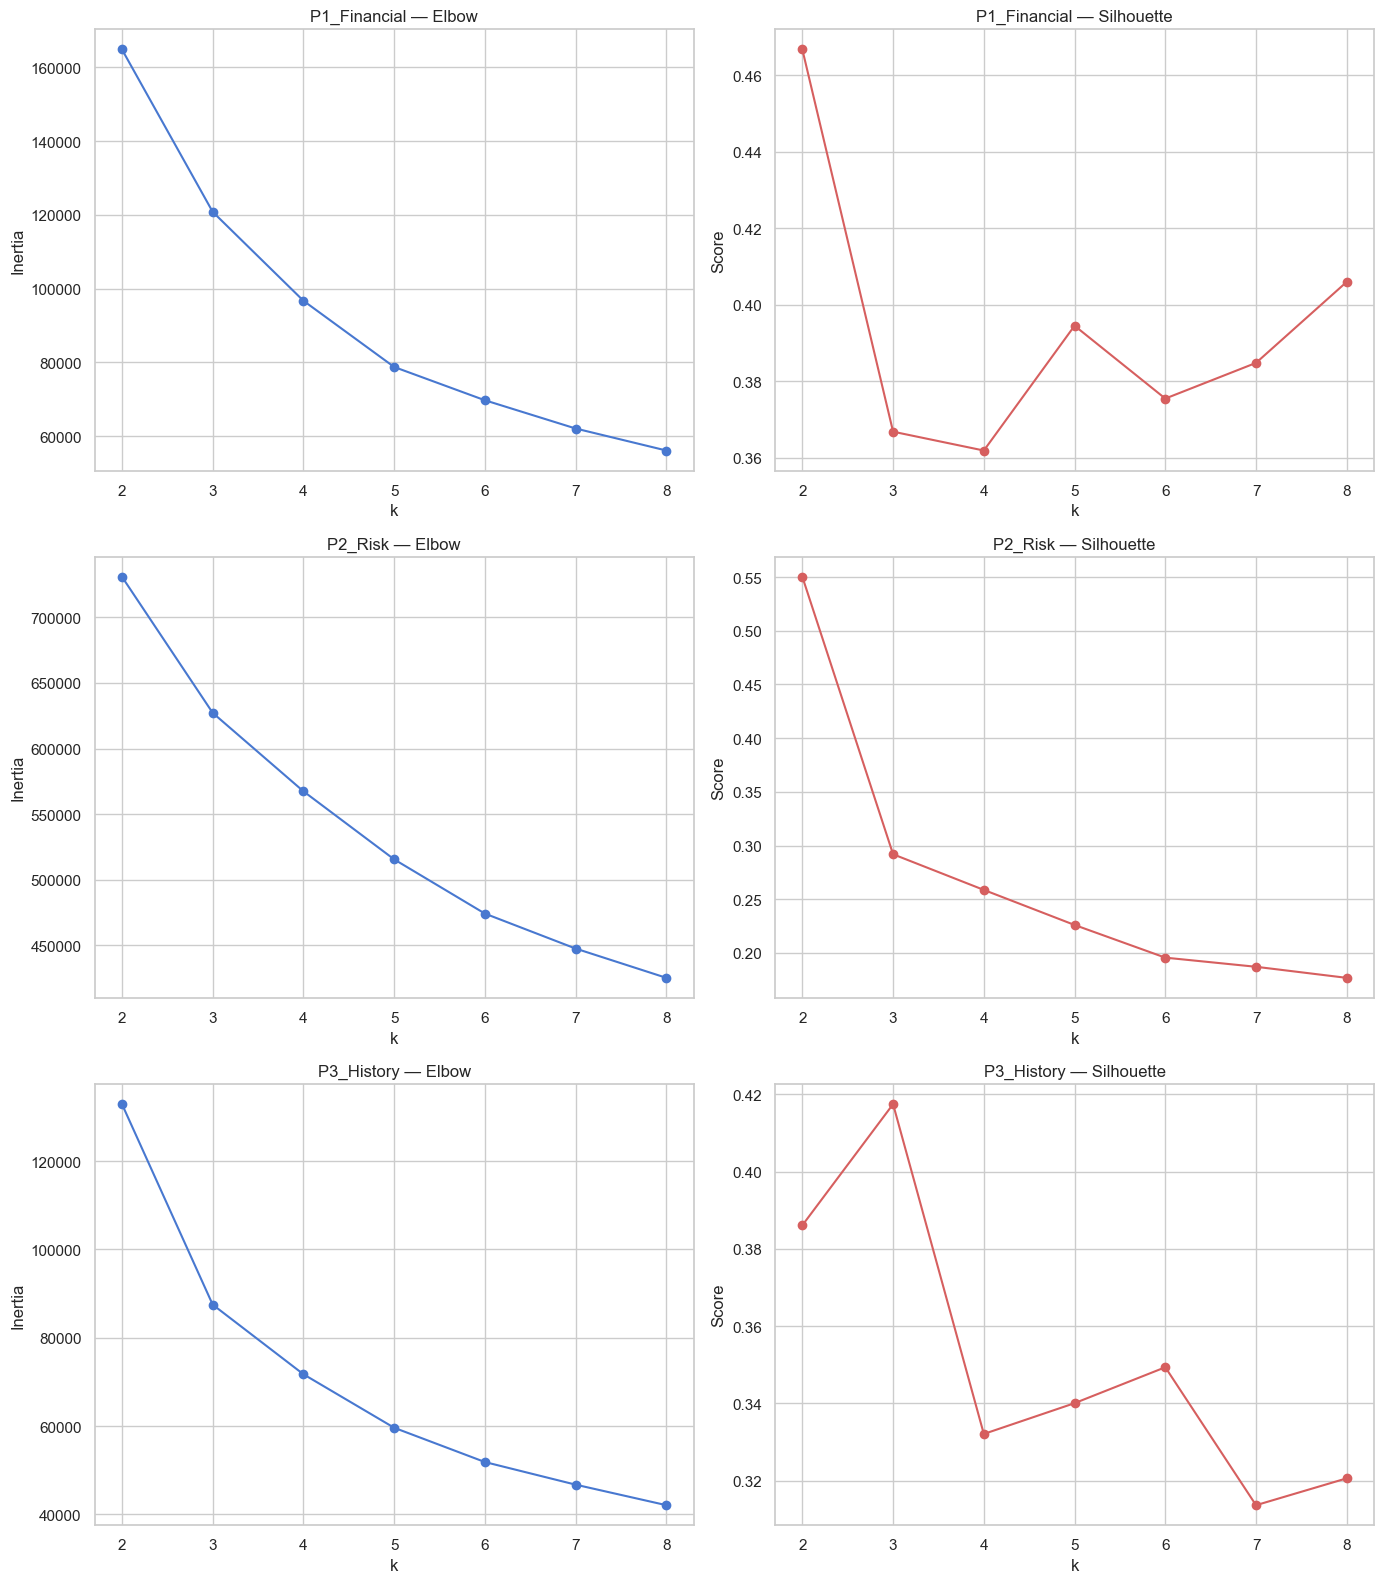

In [7]:
fig, axes = plt.subplots(len(perspectives), 2, figsize=(14, 16))

for idx, (name, cols) in enumerate(perspectives.items()):
    X = customer[cols].dropna()
    inertias, silhouettes = [], []
    K = range(2, 9)
    
    for k in K:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X, km.labels_, sample_size=10000))
    
    axes[idx, 0].plot(K, inertias, 'bo-')
    axes[idx, 0].set_title(f'{name} — Elbow')
    axes[idx, 0].set_xlabel('k')
    axes[idx, 0].set_ylabel('Inertia')
    
    axes[idx, 1].plot(K, silhouettes, 'ro-')
    axes[idx, 1].set_title(f'{name} — Silhouette')
    axes[idx, 1].set_xlabel('k')
    axes[idx, 1].set_ylabel('Score')

plt.tight_layout()
plt.show()

| Perspective | k | Notes |
|-------------|---|-------|
| P1 — Financial Profile | 3 | Elbow + Silhouette agree |
| P2 — Risk & External Credit |  3 | Elbow + Silhouette agree |
| P3 — Cetelem History | 3 | Clear peak at k=4 |

In [8]:
perspectives = {
    'P1_Financial': {'cols': p1_cols, 'k': 3},
    'P2_Risk':      {'cols': p2_cols, 'k': 3}, 
    'P3_History':   {'cols': p3_cols, 'k': 3},
}

### 2.2 K-means Clustering

In [9]:
for name, config in perspectives.items():
    cols = config['cols']
    k    = config['k']
    
    print(f"\n{'='*50}", flush=True)
    print(f"{name} | k={k} | {len(cols)} variáveis", flush=True)
    print(f"{'='*50}", flush=True)
    
    # Verificar nulos
    n_nulls = customer[cols].isnull().sum().sum()
    if n_nulls > 0:
        print(f"  {n_nulls} nulos encontrados — a remover linhas", flush=True)
    
    X = customer[cols].dropna()
    
    # Fit KMeans
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    
    # Guardar labels no dataframe
    cluster_col = f'cluster_{name}'
    customer.loc[X.index, cluster_col] = labels
    
    # Distribuição dos clusters
    dist = customer[cluster_col].value_counts().sort_index()
    print("\nDistribuição dos clusters:", flush=True)
    for cluster, count in dist.items():
        pct = count / len(X) * 100
        print(f"  Cluster {int(cluster)}: {count:>6} clientes ({pct:.1f}%)", flush=True)
    
    # Centroides — logo aqui para não perder output
    print("\nCentroides:", flush=True)
    centroids = customer.dropna(subset=[cluster_col]).groupby(cluster_col)[cols].mean().round(3)
    print(centroids.T.to_string(), flush=True)
    
    # Inércia final
    print(f"\nInércia final: {km.inertia_:,.0f}", flush=True)
    print(flush=True)
    sys.stdout.flush()

print("\n Clustering concluído para todas as perspetivas")
print(f"Colunas adicionadas: {[f'cluster_{p}' for p in perspectives.keys()]}")


P1_Financial | k=3 | 4 variáveis

Distribuição dos clusters:
  Cluster 0:  24466 clientes (19.5%)
  Cluster 1:  59288 clientes (47.2%)
  Cluster 2:  41952 clientes (33.4%)

Centroides:
cluster_P1_Financial  0.000  1.000  2.000
N_CONTRACTS           0.599  0.083  0.165
TOTAL_MTFINO          1.682  0.119 -0.332
TOTAL_MENSALIDADE     1.656 -0.046 -0.102
MEDIAN_DURDEG         0.155  0.106 -1.229

Inércia final: 120,807


P2_Risk | k=3 | 11 variáveis

Distribuição dos clusters:
  Cluster 0:  77631 clientes (61.8%)
  Cluster 1:  25099 clientes (20.0%)
  Cluster 2:  22976 clientes (18.3%)

Centroides:
cluster_P2_Risk       0.000  1.000  2.000
MAX_RANGPRO           0.112  0.119  0.110
MAX_RANGCLI           0.094  0.077  0.142
MAX_RISKA             0.025  0.136  0.022
ALLBD_IDADE_MEAN__N   0.184  0.065  0.108
COUNT_CL_MEDIAN      -0.061  1.014  2.046
COUNT_AUTO_MEDIAN     0.543  0.548  0.475
COUNT_TOTAL_MEDIAN   -0.271  0.140  0.710
DIVIDAS_TOTAL_MEDIAN  0.197  0.407  0.927
MONTVENC_TOTAL_LOG 

### 2.3 Merge clusters with Hierarchical Clustering

Each customer receives a combined label `P1_P2_P3` (e.g. `0_0_2`) from the three K-Means runs.  
Ward linkage hierarchical clustering is then applied over the centroids of each combination  
to identify natural groupings and reduce to a final set of actionable segments.


In [10]:
# Check individual cluster distributions
for col in ['cluster_P1_Financial', 'cluster_P2_Risk', 'cluster_P3_History']:
    print(f"\n{col}:")
    dist = customer[col].value_counts(normalize=True).sort_index()
    for c, pct in dist.items():
        print(f"  Cluster {int(c)}: {pct*100:.1f}%")

# Check P2 specifically — likely very imbalanced
print("\nP2 centroids:")
print(customer.groupby('cluster_P2_Risk')[p2_cols].mean().round(3).T)


cluster_P1_Financial:
  Cluster 0: 19.5%
  Cluster 1: 47.2%
  Cluster 2: 33.4%

cluster_P2_Risk:
  Cluster 0: 61.8%
  Cluster 1: 20.0%
  Cluster 2: 18.3%

cluster_P3_History:
  Cluster 0: 30.7%
  Cluster 1: 54.0%
  Cluster 2: 15.3%

P2 centroids:
cluster_P2_Risk       0.000  1.000  2.000
MAX_RANGPRO           0.112  0.119  0.110
MAX_RANGCLI           0.094  0.077  0.142
MAX_RISKA             0.025  0.136  0.022
ALLBD_IDADE_MEAN__N   0.184  0.065  0.108
COUNT_CL_MEDIAN      -0.061  1.014  2.046
COUNT_AUTO_MEDIAN     0.543  0.548  0.475
COUNT_TOTAL_MEDIAN   -0.271  0.140  0.710
DIVIDAS_TOTAL_MEDIAN  0.197  0.407  0.927
MONTVENC_TOTAL_LOG    0.055  6.313  0.095
RISK_EVER             0.040  0.396  0.034
RISK_RECENT           0.017  0.194  0.012


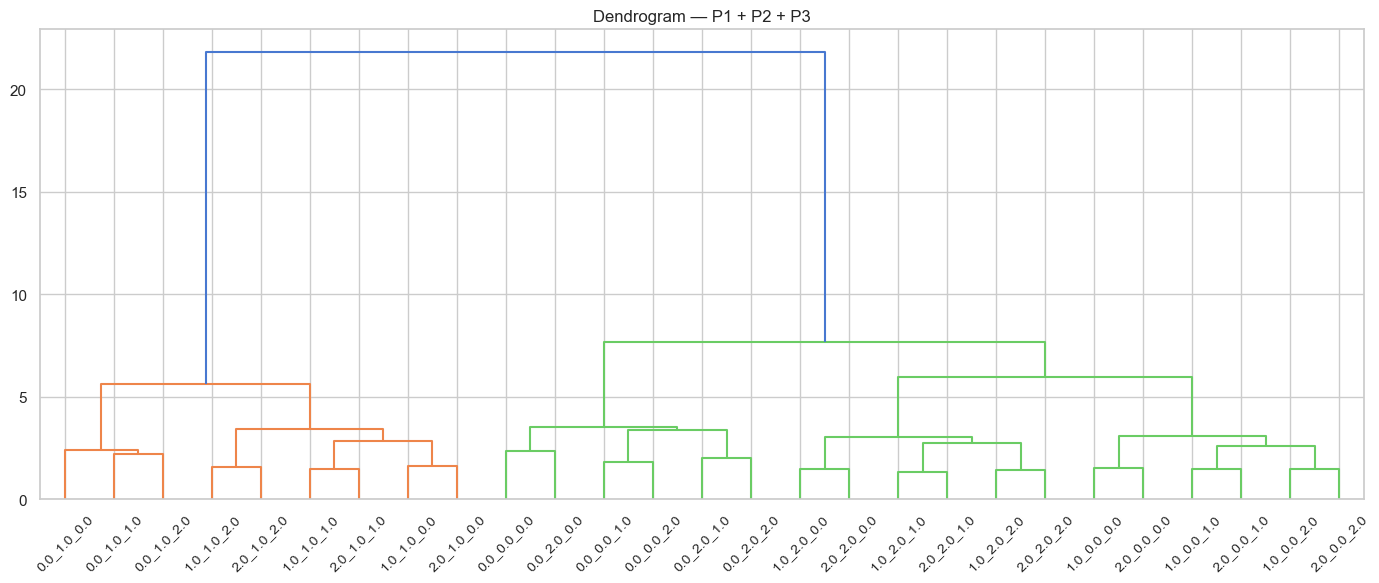

segment_final
1    25099
2    19854
3    17527
4    63226
Name: count, dtype: int64


In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# ── Create combined label ─────────────────────────────────────────────────────
customer['cluster_P1_P2_P3'] = (
    customer['cluster_P1_Financial'].astype(str) + '_' +
    customer['cluster_P2_Risk'].astype(str) + '_' +
    customer['cluster_P3_History'].astype(str)
)

# ── Hierarchical clustering on centroids ──────────────────────────────────────
all_cols = p1_cols + p2_cols + p3_cols
centroids = customer.groupby('cluster_P1_P2_P3')[all_cols].mean()

Z = linkage(centroids, method='ward')

# Dendrogram
plt.figure(figsize=(14, 6))
dendrogram(Z, labels=centroids.index.tolist(), leaf_rotation=45, leaf_font_size=10)
plt.title('Dendrogram — P1 + P2 + P3')
plt.tight_layout()
plt.show()

# ── Final segmentation — adjust n_final after seeing dendrogram ───────────────
n_final = 4

customer['segment_final'] = customer['cluster_P1_P2_P3'].map(
    dict(zip(centroids.index, fcluster(Z, n_final, criterion='maxclust')))
)

print(customer['segment_final'].value_counts().sort_index())

## 3. Profiling

In [12]:
# ── Profiling dos 4 segmentos finais ─────────────────────────────────────────

all_feature_cols = p1_cols + p2_cols + p3_cols

sitfam_cols = ['sdem_SITFAM_D', 'sdem_SITFAM_P', 'sdem_SITFAM_S',
               'sdem_SITFAM_U', 'sdem_SITFAM_Unknown',
               'sdem_SITFAM_V', 'sdem_SITFAM_X']

habitat_cols = ['sdem_HABITAT_A', 'sdem_HABITAT_E', 'sdem_HABITAT_F',
                'sdem_HABITAT_L', 'sdem_HABITAT_O', 'sdem_HABITAT_P',
                'sdem_HABITAT_Unknown', 'sdem_HABITAT_X']

continuous_profiling = ['sdem_age', 'CSP', 'NBENF', 'MEDIAN_RESSO',
                        'ALLBD_IDADE_MEAN__N', 'RISK_TOTAL',
                        'EXTERNAL_TO_CETELEM']

seg_col = 'segment_final'
valid = customer.dropna(subset=[seg_col])
segments = sorted(valid[seg_col].unique())


In [13]:
# ── 1. Distribution ───────────────────────────────────────────────────────────
print("=" * 60)
print("SEGMENT DISTRIBUTION")
print("=" * 60)
for s in segments:
    count = (valid[seg_col] == s).sum()
    pct = count / len(valid) * 100
    print(f"  Segment {int(s)}: {count:>8,} ({pct:.1f}%)")

# ── 2. Feature centroids ──────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("CENTROIDS — CLUSTERING VARIABLES")
print("=" * 60)
centroids_seg = valid.groupby(seg_col)[all_feature_cols].mean().round(3)
print(centroids_seg.T.to_string())

SEGMENT DISTRIBUTION
  Segment 1:   25,099 (20.0%)
  Segment 2:   19,854 (15.8%)
  Segment 3:   17,527 (13.9%)
  Segment 4:   63,226 (50.3%)

CENTROIDS — CLUSTERING VARIABLES
segment_final                  1     2      3      4
N_CONTRACTS                0.175 0.628  0.179  0.103
TOTAL_MTFINO               0.239 1.671 -0.055 -0.063
TOTAL_MENSALIDADE          0.199 1.659 -0.094 -0.043
MEDIAN_DURDEG             -0.246 0.122 -0.358 -0.498
MAX_RANGPRO                0.119 0.253  0.051  0.084
MAX_RANGCLI                0.077 0.258  0.086  0.062
MAX_RISKA                  0.136 0.026  0.021  0.025
ALLBD_IDADE_MEAN__N        0.065 0.123  0.124  0.192
COUNT_CL_MEDIAN            1.014 0.567  2.041 -0.075
COUNT_AUTO_MEDIAN          0.548 0.486  0.483  0.552
COUNT_TOTAL_MEDIAN         0.140 0.051  0.692 -0.283
DIVIDAS_TOTAL_MEDIAN       0.407 0.534  0.891  0.165
MONTVENC_TOTAL_LOG         6.313 0.062  0.097  0.055
RISK_EVER                  0.396 0.037  0.032  0.041
RISK_RECENT                0.1

In [14]:
# ── 3. Continuous profiling ───────────────────────────────────────────────────
print("\n" + "=" * 60)
print("CONTINUOUS PROFILING")
print("=" * 60)
available = [c for c in continuous_profiling if c in valid.columns]
print(f"{'Variable':<25}", end='')
for s in segments:
    print(f"  Seg {int(s):>1}", end='')
print()
print("-" * (25 + len(segments) * 8))
for col in available:
    print(f"  {col:<23}", end='')
    for s in segments:
        val = valid[valid[seg_col] == s][col].mean()
        print(f"  {val:>6.2f}", end='')
    print()


CONTINUOUS PROFILING
Variable                   Seg 1  Seg 2  Seg 3  Seg 4
---------------------------------------------------------
  sdem_age                  -0.06    0.10    0.05    0.06
  CSP                       -0.27   -0.34   -0.39   -0.26
  NBENF                      0.62    0.64    0.70    0.57
  MEDIAN_RESSO               0.17    0.50    0.51    0.15
  ALLBD_IDADE_MEAN__N        0.06    0.12    0.12    0.19
  EXTERNAL_TO_CETELEM        0.26   -0.11    0.77   -0.10


In [15]:
# ── 4. SITFAM ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("FAMILY SITUATION (% per segment)")
print("=" * 60)
sitfam_avail = [c for c in sitfam_cols if c in valid.columns]
sitfam_profile = valid.groupby(seg_col)[sitfam_avail].mean().mul(100).round(1)
sitfam_profile.columns = [c.replace('sdem_SITFAM_', '') for c in sitfam_avail]
print(sitfam_profile.T.to_string())



FAMILY SITUATION (% per segment)
segment_final      1      2      3      4
D              5.800  6.800  7.300  6.400
P              2.500  1.900  1.500  2.100
S             18.500 17.400 18.200 19.100
U              9.900 10.800  9.000  8.600
Unknown        4.100  2.000  3.300  4.300
V              1.600  1.700  1.300  1.800
X             24.900 14.100 17.500 21.300


In [16]:
# ── 5. HABITAT ────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("HABITAT (% per segment)")
print("=" * 60)
habitat_avail = [c for c in habitat_cols if c in valid.columns]
habitat_profile = valid.groupby(seg_col)[habitat_avail].mean().mul(100).round(1)
habitat_profile.columns = [c.replace('sdem_HABITAT_', '') for c in habitat_avail]
print(habitat_profile.T.to_string())


HABITAT (% per segment)
segment_final      1      2      3      4
E              0.100  0.000  0.100  0.100
F             33.700 26.800 22.200 28.300
L             10.600  7.900  7.300 11.600
O              0.200  0.100  0.100  0.100
P             25.000 30.100 23.300 26.800
Unknown        4.100  2.000  3.300  4.300
X              0.100  0.100  0.100  0.100


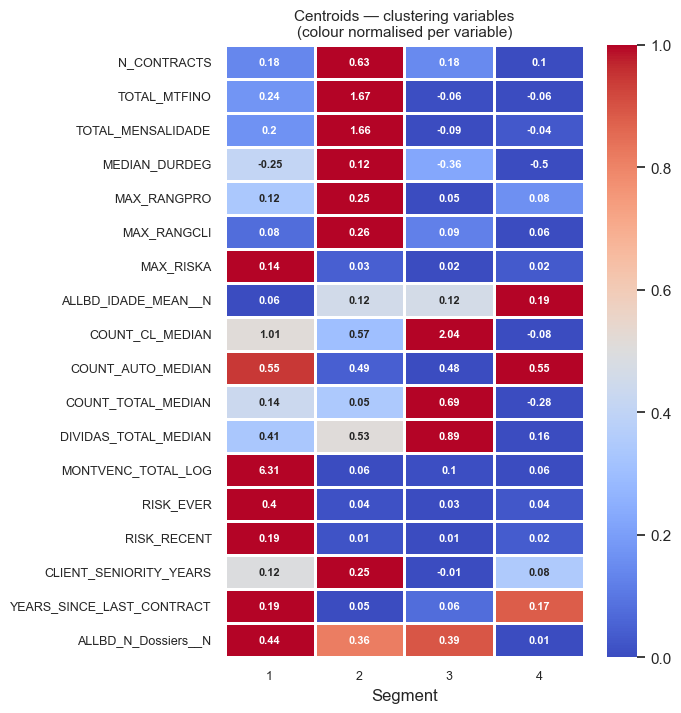

In [17]:
# ── Plot 1 — Centroids (numeric clustering variables) ─────────────────────────
fig, ax = plt.subplots(figsize=(7, len(all_feature_cols) * 0.35 + 1))

centroids_normalized = centroids_seg.copy()
for col in centroids_seg.columns:
    row = centroids_seg[col]
    row_min, row_max = row.min(), row.max()
    if row_max - row_min > 0:
        centroids_normalized[col] = (row - row_min) / (row_max - row_min)
    else:
        centroids_normalized[col] = 0.5

sns.heatmap(centroids_normalized.T, annot=centroids_seg.T.round(2),
            fmt='', cmap='coolwarm', vmin=0, vmax=1,
            ax=ax, linewidths=0.8, linecolor='white',
            annot_kws={'size': 8,'weight': 'bold'})
ax.set_title('Centroids — clustering variables\n(colour normalised per variable)', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=9)
ax.set_xlabel('Segment')
plt.tight_layout()
plt.show()

Text(0.5, 33.249999999999986, 'Segment')

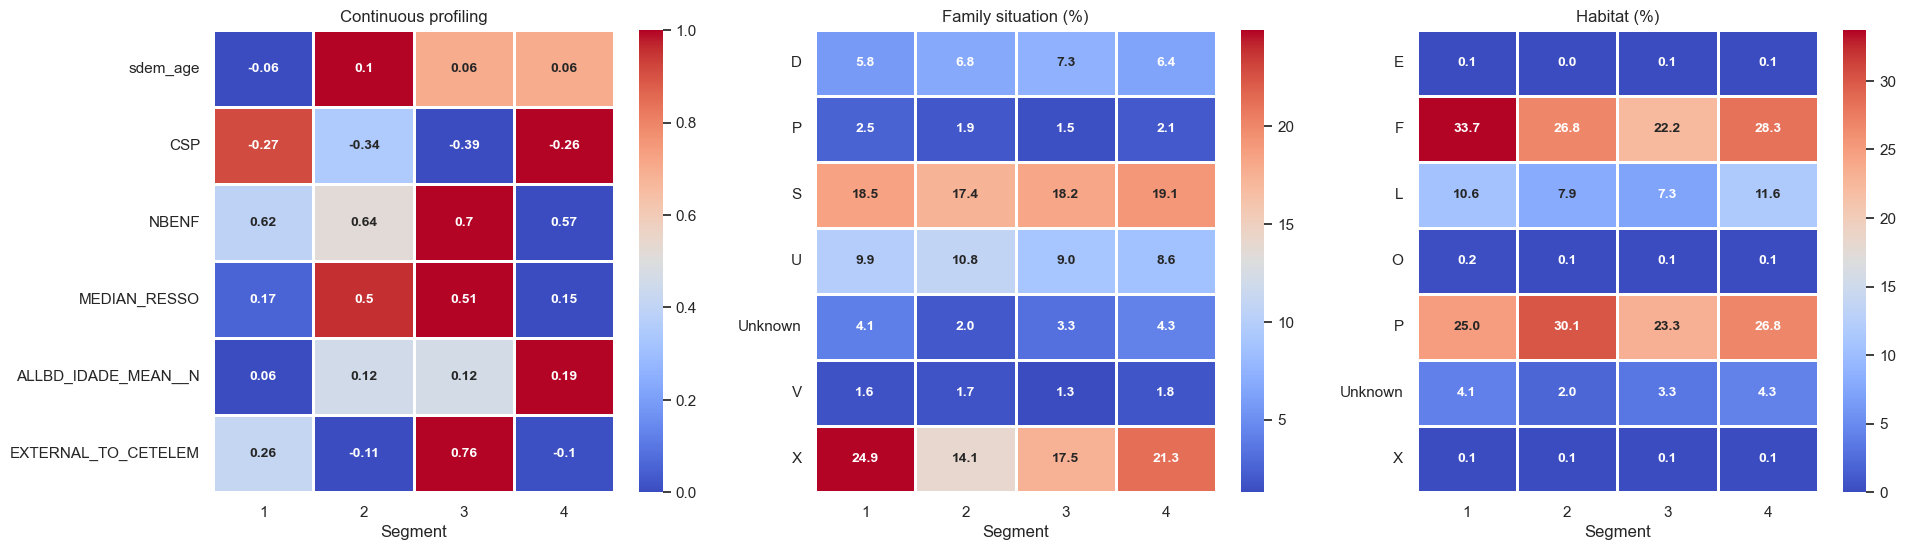

In [18]:
# ── Plot 2 — Continuous profiling + Family situation + Habitat ────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Continuous profiling
available = [c for c in continuous_profiling if c in valid.columns]
profiling_means = valid.groupby(seg_col)[available].mean().round(3)
profiling_normalized = profiling_means.copy()
for col in profiling_means.columns:
    row = profiling_means[col]
    row_min, row_max = row.min(), row.max()
    if row_max - row_min > 0:
        profiling_normalized[col] = (row - row_min) / (row_max - row_min)
    else:
        profiling_normalized[col] = 0.5

sns.heatmap(profiling_normalized.T, annot=profiling_means.T.round(2),
            fmt='', cmap='coolwarm', vmin=0, vmax=1,
            ax=axes[0], linewidths=0.8, linecolor='white',
            annot_kws={'size': 10, 'weight': 'bold'})
axes[0].set_title('Continuous profiling')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)
axes[0].set_xlabel('Segment')

# Family situation
sns.heatmap(sitfam_profile.T, annot=True, fmt='.1f', cmap='coolwarm',
            ax=axes[1], linewidths=0.8, linecolor='white',
            annot_kws={'size': 10, 'weight': 'bold'})
axes[1].set_title('Family situation (%)')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)
axes[1].set_xlabel('Segment')

# Habitat
sns.heatmap(habitat_profile.T, annot=True, fmt='.1f', cmap='coolwarm',
            ax=axes[2], linewidths=0.8, linecolor='white',
            annot_kws={'size': 10, 'weight': 'bold'})
axes[2].set_title('Habitat (%)')
axes[2].set_yticklabels(axes[2].get_yticklabels(), rotation=0)
axes[2].set_xlabel('Segment')

In [19]:
abt = io.load(ABT_OUT_PATH)

[LOAD] ../data/prepared/abt.parquet | shape: (148729, 88)


In [20]:
target_columns = [
    'EVER_SOL', 'N_SOL', 
    'EVER_SAN', 'N_SAN', 
    'EVER_RBT', 'N_RBT', 
    'IS_EARLY_SETTLER', 'IS_CHURN'
]

In [21]:
# Check target columns
print(abt[target_columns].describe())
print(abt[target_columns].mean())

# Merge targets into customer dataset by client ID
# Only bring the target columns — nothing else
customer = customer.merge(
    abt[['CONTRIB'] + target_columns],
    on='CONTRIB',
    how='left'
)

# Confirm merge
print(f"\nDataset after merge: {len(customer):,} clients")
print(f"IS_CHURN distribution:")
print(customer['IS_CHURN'].value_counts(normalize=True).mul(100).round(1))
print(f"\nIS_EARLY_SETTLER distribution:")
print(customer['IS_EARLY_SETTLER'].value_counts(normalize=True).mul(100).round(1))


        EVER_SOL      N_SOL   EVER_SAN      N_SAN   EVER_RBT      N_RBT  IS_EARLY_SETTLER   IS_CHURN
count 148729.000 148729.000 148729.000 148729.000 148729.000 148729.000        148729.000 148729.000
mean       0.183      0.190      0.273      0.328      0.021      0.022             0.278      0.446
std        0.387      0.409      0.446      0.606      0.143      0.154             0.448      0.497
min        0.000      0.000      0.000      0.000      0.000      0.000             0.000      0.000
25%        0.000      0.000      0.000      0.000      0.000      0.000             0.000      0.000
50%        0.000      0.000      0.000      0.000      0.000      0.000             0.000      0.000
75%        0.000      0.000      1.000      1.000      0.000      0.000             1.000      1.000
max        1.000      7.000      1.000      9.000      1.000      4.000             1.000      1.000
EVER_SOL           0.183
N_SOL              0.190
EVER_SAN           0.273
N_SAN           

In [22]:
# IS_CHURN = 1 se cliente não fez novo contrato em 30/60 dias após liquidação?
# Ou IS_CHURN = 1 para todos os clientes sem contrato activo?
# A definição impacta muito a interpretação
print(abt[['IS_CHURN', 'IS_EARLY_SETTLER']].value_counts())

IS_CHURN  IS_EARLY_SETTLER
0         0                   81550
1         1                   40518
          0                   25804
0         1                     857
Name: count, dtype: int64


In [23]:
print(f"Early settlers that churn: {40518/(40518+857)*100:.1f}%")

Early settlers that churn: 97.9%


In [24]:
customer[
    (customer['IS_CHURN'] == 1) & 
    (customer['IS_EARLY_SETTLER'] == 0)
][['EVER_SOL', 'EVER_RBT', 'N_SOL', 'N_RBT']].value_counts().head(10)

EVER_SOL  EVER_RBT  N_SOL  N_RBT
1         0         1      0        20056
                    2      0          489
                    3      0           24
                    4      0            1
                    7      0            1
Name: count, dtype: int64

In [25]:
# Two churn types — aligned with Cetelem business case
customer['CHURN_EARLY'] = customer['IS_EARLY_SETTLER']  # Objective 1
customer['CHURN_NATURAL'] = (                            # Objective 2
    (customer['EVER_SOL'] == 1) & 
    (customer['IS_EARLY_SETTLER'] == 0)
).astype(int)

# Verify
print("Churn type distribution:")
print(f"  No churn:      {(customer['IS_CHURN']==0).mean()*100:.1f}%")
print(f"  Early churn:   {customer['CHURN_EARLY'].mean()*100:.1f}%")
print(f"  Natural churn: {customer['CHURN_NATURAL'].mean()*100:.1f}%")

# Churn rate by segment — the key analysis
churn_by_segment = customer.groupby('segment_final').agg(
    n_clients      = ('IS_CHURN', 'count'),
    churn_rate     = ('IS_CHURN', 'mean'),
    churn_early    = ('CHURN_EARLY', 'mean'),
    churn_natural  = ('CHURN_NATURAL', 'mean'),
).round(3).mul({'n_clients': 1, 'churn_rate': 100, 
                'churn_early': 100, 'churn_natural': 100})

print("\nChurn rate by segment:")
print(churn_by_segment.to_string())

Churn type distribution:
  No churn:      56.3%
  Early churn:   27.8%
  Natural churn: 16.5%

Churn rate by segment:
               n_clients  churn_rate  churn_early  churn_natural
segment_final                                                   
1                  25099      37.300       25.500         12.300
2                  19854      51.300       45.800          7.400
3                  17527      39.300       27.300         12.400
4                  63226      45.100       23.300         22.200


Running PCA...
Running t-SNE (this may take a moment)...
Running UMAP...


c:\Users\Asus\anaconda3\envs\Fall2526\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


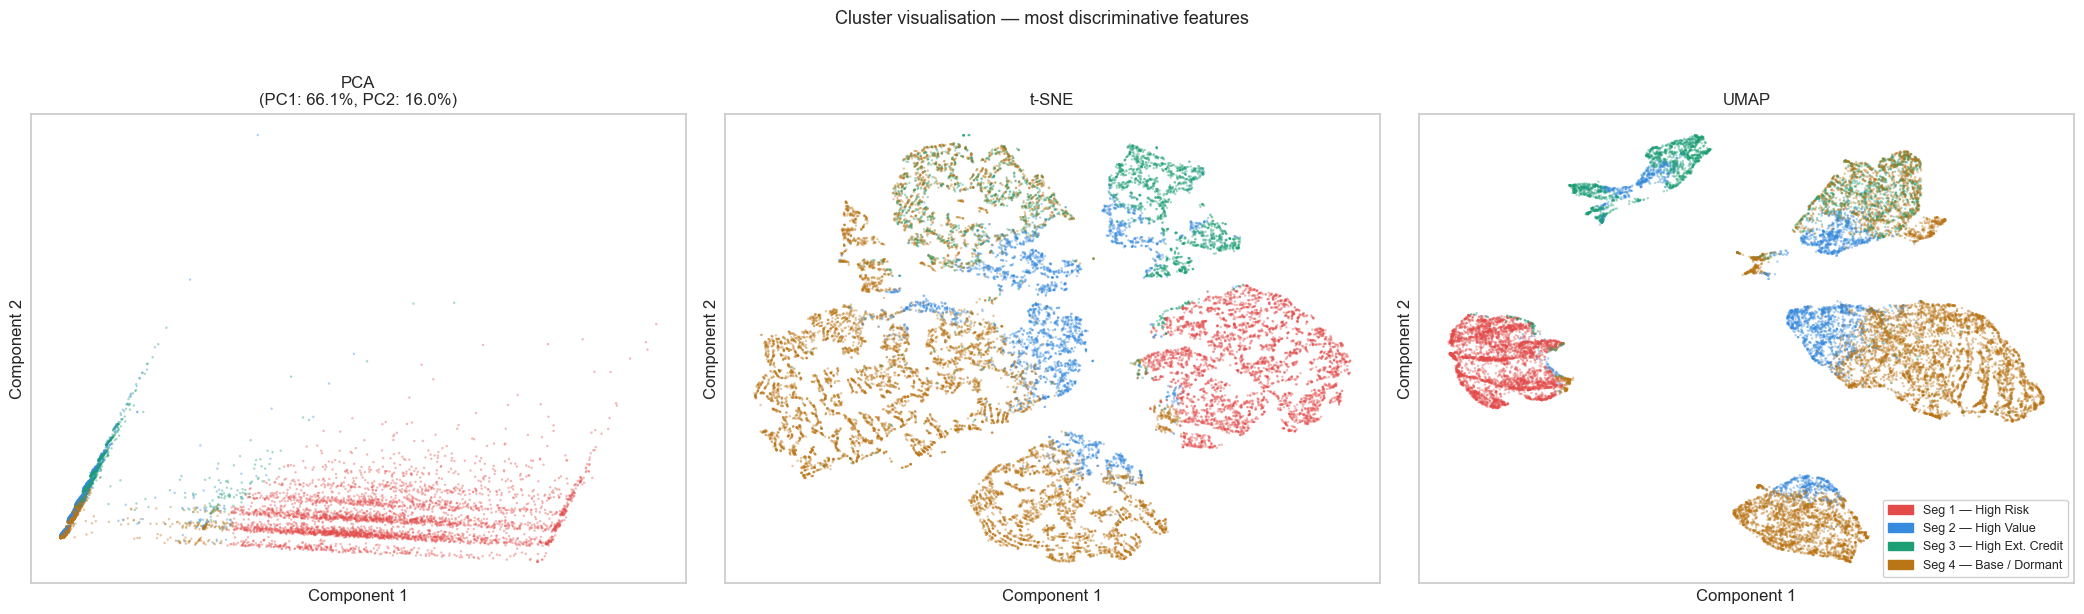


Sample used: 20,000 clients
PCA variance explained: 82.1%


In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ── Configuration ─────────────────────────────────────────────────────────────
# Most discriminative variables based on centroid analysis
viz_cols = [
    'TOTAL_MTFINO',          # P1 — high value contracts
    'MONTVENC_TOTAL_LOG',    # P2 — overdue amounts
    'COUNT_CL_MEDIAN',       # P2 — external credit count
    'ALLBD_N_Dossiers__N',   # P3 — cetelem history
    'CLIENT_SENIORITY_YEARS',# P3 — seniority
    'RISK_EVER'              # P2 — risk flag
]

# Segment colours — consistent across all plots
segment_colors = {1: '#E24B4A', 2: '#378ADD', 3: '#1D9E75', 4: '#BA7517'}
segment_names  = {
    1: 'Seg 1 — High Risk',
    2: 'Seg 2 — High Value', 
    3: 'Seg 3 — High Ext. Credit',
    4: 'Seg 4 — Base / Dormant'
}

# Prepare data — sample for performance
sample_size = 20000
df_viz = customer[viz_cols + ['segment_final', 'IS_CHURN']].dropna()
df_sample = df_viz.sample(n=min(sample_size, len(df_viz)), random_state=42)

X = df_sample[viz_cols].values
colors = df_sample['segment_final'].map(segment_colors).values

# Legend
legend_patches = [
    mpatches.Patch(color=c, label=segment_names[s]) 
    for s, c in segment_colors.items()
]

# ── PCA ───────────────────────────────────────────────────────────────────────
print("Running PCA...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
var_explained = pca.explained_variance_ratio_ * 100

# ── t-SNE ─────────────────────────────────────────────────────────────────────
print("Running t-SNE (this may take a moment)...")
tsne = TSNE(n_components=2, random_state=42, 
            perplexity=50, max_iter=1000, verbose=0)
X_tsne = tsne.fit_transform(X)

# ── UMAP ──────────────────────────────────────────────────────────────────────
print("Running UMAP...")
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42,
                        n_neighbors=30, min_dist=0.1)
    X_umap = reducer.fit_transform(X)
    umap_available = True
except ImportError:
    print("UMAP not installed — run: pip install umap-learn")
    umap_available = False

# ── Plot ──────────────────────────────────────────────────────────────────────
n_plots = 2 + (1 if umap_available else 0)
fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 6))

plot_data = [
    (X_pca,  f'PCA\n(PC1: {var_explained[0]:.1f}%, PC2: {var_explained[1]:.1f}%)'),
    (X_tsne, 't-SNE'),
]
if umap_available:
    plot_data.append((X_umap, 'UMAP'))

for ax, (X_2d, title) in zip(axes, plot_data):
    ax.scatter(X_2d[:, 0], X_2d[:, 1],
               c=colors, alpha=0.4, s=3, linewidths=0)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_xticks([])
    ax.set_yticks([])

# Shared legend
axes[-1].legend(handles=legend_patches, loc='lower right',
                fontsize=9, framealpha=0.9)

plt.suptitle('Cluster visualisation — most discriminative features', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nSample used: {len(df_sample):,} clients")
print(f"PCA variance explained: {sum(var_explained):.1f}%")

c:\Users\Asus\anaconda3\envs\Fall2526\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


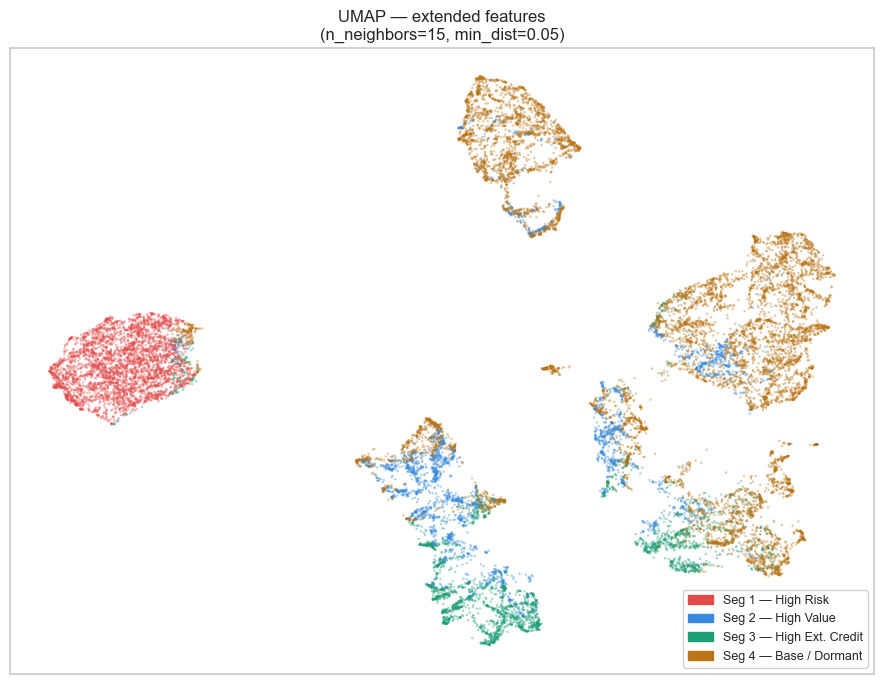

In [27]:
# ── UMAP with extended features ───────────────────────────────────────────────
viz_cols_extended = [
    'TOTAL_MTFINO',
    'N_CONTRACTS',
    'MEDIAN_DURDEG',
    'MONTVENC_TOTAL_LOG',
    'COUNT_CL_MEDIAN',
    'DIVIDAS_TOTAL_MEDIAN',
    'RISK_EVER',
    'RISK_RECENT',
    'ALLBD_N_Dossiers__N',
    'CLIENT_SENIORITY_YEARS',
    'YEARS_SINCE_LAST_CONTRACT'
]

# Sample
df_viz2 = customer[viz_cols_extended + ['segment_final']].dropna()
df_sample2 = df_viz2.sample(n=min(20000, len(df_viz2)), random_state=42)

X2 = df_sample2[viz_cols_extended].values
colors2 = df_sample2['segment_final'].map(segment_colors).values

# UMAP — tighter clusters
import umap
reducer2 = umap.UMAP(n_components=2, random_state=42,
                     n_neighbors=15, min_dist=0.05)
X_umap2 = reducer2.fit_transform(X2)

# Plot
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_umap2[:, 0], X_umap2[:, 1],
           c=colors2, alpha=0.4, s=3, linewidths=0)
ax.set_title('UMAP — extended features\n(n_neighbors=15, min_dist=0.05)', fontsize=12)
ax.set_xticks([])
ax.set_yticks([])
ax.legend(handles=legend_patches, loc='lower right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

=== MEDIAN_RESSO — original distribution ===

count    148729.000
mean       1469.250
std        5532.120
min           0.000
25%         963.830
50%        1230.630
75%        1731.810
max     1665025.600
Name: MEDIAN_RESSO, dtype: float64

Missing:  0 (0.0%)
Zeros:    9,049 (6.1%)
Negative: 0 (0.0%)

Percentiles:
  P 1:       0.00
  P 5:       0.00
  P10:     682.49
  P25:     963.83
  P50:    1230.63
  P75:    1731.81
  P90:    2458.80
  P95:    3081.06
  P99:    5052.15

Valid values (> 0): 139,680 (93.9%)
count    139680.000
mean       1564.440
std        5695.450
min           0.500
25%        1015.360
50%        1267.610
75%        1776.170
max     1665025.600
Name: MEDIAN_RESSO, dtype: float64


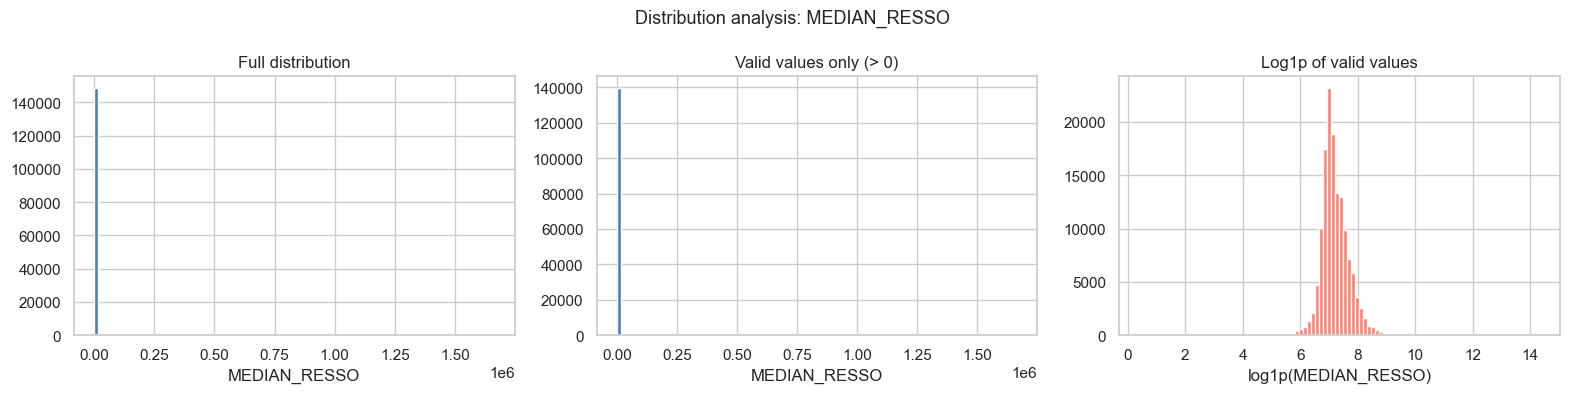

In [28]:

col = 'MEDIAN_RESSO'

# Load from ABT (original, unscaled)
resso_original = abt[col]

print("=== MEDIAN_RESSO — original distribution ===\n")
print(resso_original.describe().round(2))

print(f"\nMissing:  {resso_original.isna().sum():,} ({resso_original.isna().mean()*100:.1f}%)")
print(f"Zeros:    {(resso_original == 0).sum():,} ({(resso_original == 0).mean()*100:.1f}%)")
print(f"Negative: {(resso_original < 0).sum():,} ({(resso_original < 0).mean()*100:.1f}%)")

print(f"\nPercentiles:")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"  P{p:>2}: {resso_original.quantile(p/100):>10.2f}")

# Distribution of non-zero, non-negative values
valid = resso_original[(resso_original > 0) & resso_original.notna()]
print(f"\nValid values (> 0): {len(valid):,} ({len(valid)/len(resso_original)*100:.1f}%)")
print(valid.describe().round(2))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Full distribution
axes[0].hist(resso_original.dropna(), bins=100, 
             color='steelblue', edgecolor='white')
axes[0].set_title('Full distribution')
axes[0].set_xlabel(col)

# Valid only (> 0)
axes[1].hist(valid, bins=100, color='steelblue', edgecolor='white')
axes[1].set_title('Valid values only (> 0)')
axes[1].set_xlabel(col)

# Log1p of valid
axes[2].hist(np.log1p(valid), bins=100, color='salmon', edgecolor='white')
axes[2].set_title('Log1p of valid values')
axes[2].set_xlabel(f'log1p({col})')

plt.suptitle(f'Distribution analysis: {col}', fontsize=13)
plt.tight_layout()
plt.show()